# 📊 Unemployment in India — Data Analytics

> **Unemployment rate** = Number of unemployed people ÷ Total labour force × 100

During **Covid-19 (2020)**, India witnessed a dramatic spike in unemployment. This notebook explores unemployment trends across Indian states, rural vs urban areas, and across time using **NumPy, Pandas, Matplotlib, and Seaborn**.

---


## 1. 📦 Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Set visual style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


## 2. 📂 Load the Dataset

In [2]:
df = pd.read_csv("unemployeementinindia.csv")

# Clean column names (strip whitespace)
df.columns = df.columns.str.strip()

# Rename columns for ease of use
df.rename(columns={
    'Date': 'Date',
    'Frequency': 'Frequency',
    'Estimated Unemployment Rate (%)': 'Unemployment_Rate',
    'Estimated Employed': 'Employed',
    'Estimated Labour Participation Rate (%)': 'Labour_Participation_Rate'
}, inplace=True)

# Parse date
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

print("Shape:", df.shape)
df.head(10)


Shape: (768, 7)


,Region,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural
5,Andhra Pradesh,2019-10-31,Monthly,3.52,12017412.0,43.01,Rural
6,Andhra Pradesh,2019-11-30,Monthly,4.12,11397681.0,41.00,Rural
7,Andhra Pradesh,2019-12-31,Monthly,4.38,12528395.0,45.14,Rural
8,Andhra Pradesh,2020-01-31,Monthly,4.84,12016676.0,43.46,Rural
9,Andhra Pradesh,2020-02-29,Monthly,5.91,11723617.0,42.83,Rural


## 3. 🔍 Data Overview & Basic Info

In [3]:
print("=" * 50)
print("Dataset Info")
print("=" * 50)
df.info()


Dataset Info
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Region                     740 non-null    str           
 1   Date                       740 non-null    datetime64[us]
 2   Frequency                  740 non-null    str           
 3   Unemployment_Rate          740 non-null    float64       
 4   Employed                   740 non-null    float64       
 5   Labour_Participation_Rate  740 non-null    float64       
 6   Area                       740 non-null    str           
dtypes: datetime64[us](1), float64(3), str(3)
memory usage: 42.1 KB


In [4]:
print("\n📊 Statistical Summary:")
df.describe().round(2)



📊 Statistical Summary:


,Date,Unemployment_Rate,Employed,Labour_Participation_Rate
count,740,740.00,740.00,740.00
mean,2019-12-12 18:36:58.378378,11.79,7204460.03,42.63
min,2019-05-31 00:00:00,0.00,49420.00,13.33
25%,2019-08-31 00:00:00,4.66,1190404.50,38.06
50%,2019-11-30 00:00:00,8.35,4744178.50,41.16
75%,2020-03-31 00:00:00,15.89,11275489.50,45.50
max,2020-06-30 00:00:00,76.74,45777509.00,72.57
std,NaN,10.72,8087988.43,8.11


In [5]:
print("Missing Values per Column:")
print(df.isnull().sum())


Missing Values per Column:
Region                       28
Date                         28
Frequency                    28
Unemployment_Rate            28
Employed                     28
Labour_Participation_Rate    28
Area                         28
dtype: int64


In [6]:
# Drop rows with missing values
df.dropna(inplace=True)

print(f"✅ Clean dataset shape: {df.shape}")
print(f"\nUnique Regions: {df['Region'].nunique()}")
print(f"Date Range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Areas: {df['Area'].unique()}")


✅ Clean dataset shape: (740, 7)

Unique Regions: 28
Date Range: 2019-05-31 to 2020-06-30
Areas: <StringArray>
['Rural', 'Urban']
Length: 2, dtype: str


## 4. 📈 Unemployment Rate Over Time (India Overall)

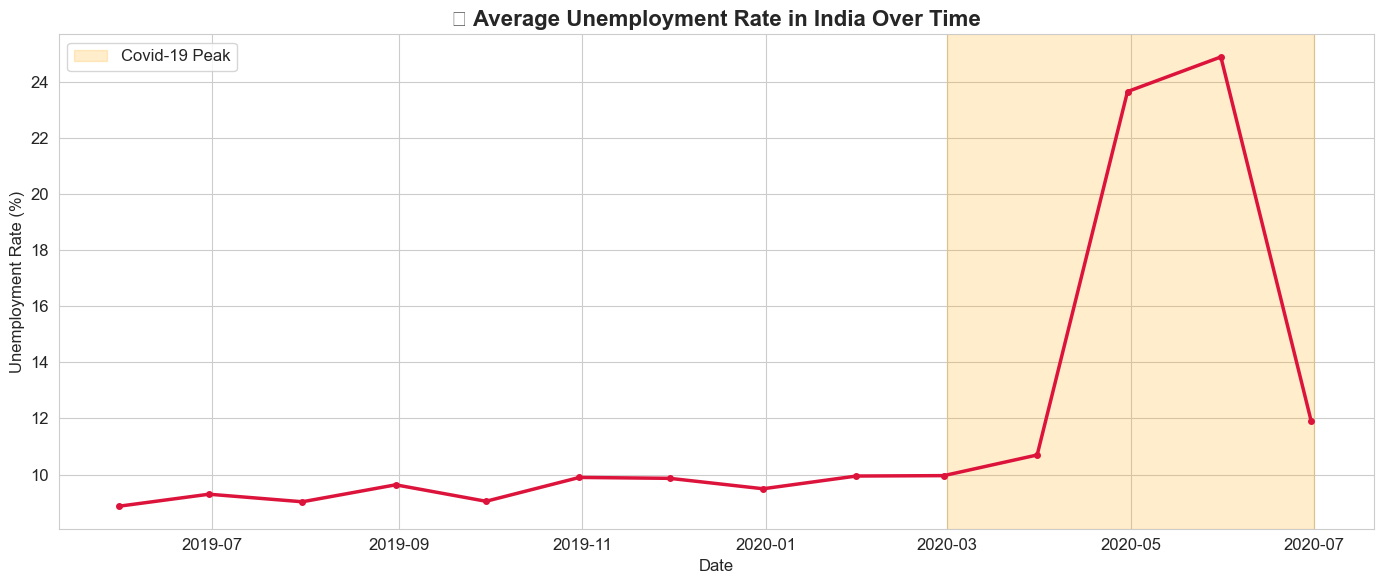


Peak Unemployment Month: May 2020
Peak Unemployment Rate:  24.88%


In [7]:
monthly_avg = df.groupby('Date')['Unemployment_Rate'].mean().reset_index()

plt.figure(figsize=(14, 6))
plt.plot(monthly_avg['Date'], monthly_avg['Unemployment_Rate'], color='crimson', linewidth=2.5, marker='o', markersize=4)
plt.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-07-01'), alpha=0.2, color='orange', label='Covid-19 Peak')
plt.title('📈 Average Unemployment Rate in India Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nPeak Unemployment Month: {monthly_avg.loc[monthly_avg['Unemployment_Rate'].idxmax(), 'Date'].strftime('%B %Y')}")
print(f"Peak Unemployment Rate:  {monthly_avg['Unemployment_Rate'].max():.2f}%")


## 5. 🏙️ Rural vs Urban Unemployment Comparison

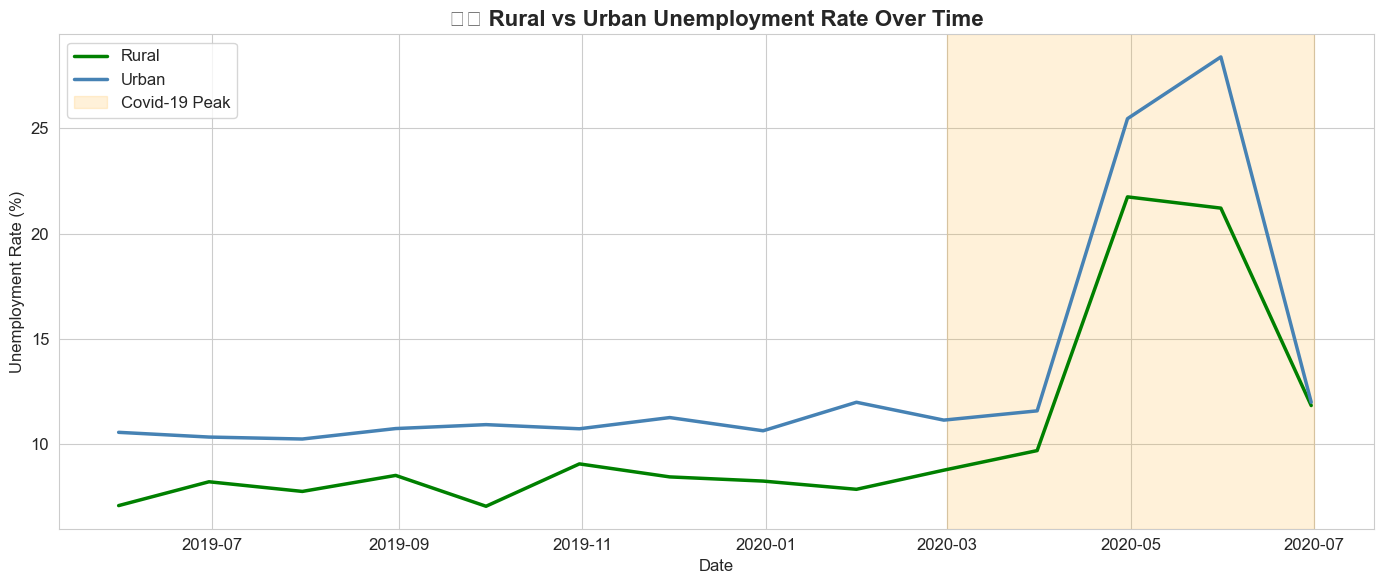

In [8]:
area_monthly = df.groupby(['Date', 'Area'])['Unemployment_Rate'].mean().reset_index()

plt.figure(figsize=(14, 6))
for area, color in zip(['Rural', 'Urban'], ['green', 'steelblue']):
    subset = area_monthly[area_monthly['Area'] == area]
    plt.plot(subset['Date'], subset['Unemployment_Rate'], label=area, color=color, linewidth=2.5)

plt.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-07-01'), alpha=0.15, color='orange', label='Covid-19 Peak')
plt.title('🏙️ Rural vs Urban Unemployment Rate Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.tight_layout()
plt.show()


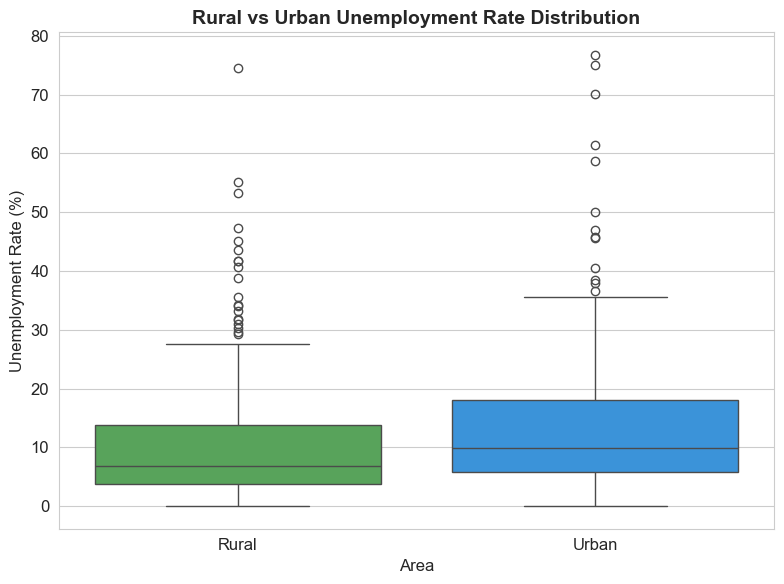

       count   mean    std  min   25%   50%    75%    max
Area                                                     
Rural  359.0  10.32  10.04  0.0  3.79  6.76  13.76  74.51
Urban  381.0  13.17  11.17  0.0  5.82  9.97  18.04  76.74


In [9]:
# Box plot comparison
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Area', y='Unemployment_Rate', palette=['#4CAF50', '#2196F3'])
plt.title('Rural vs Urban Unemployment Rate Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Area')
plt.ylabel('Unemployment Rate (%)')
plt.tight_layout()
plt.show()

print(df.groupby('Area')['Unemployment_Rate'].describe().round(2))


## 6. 🗺️ State-wise Average Unemployment Rate

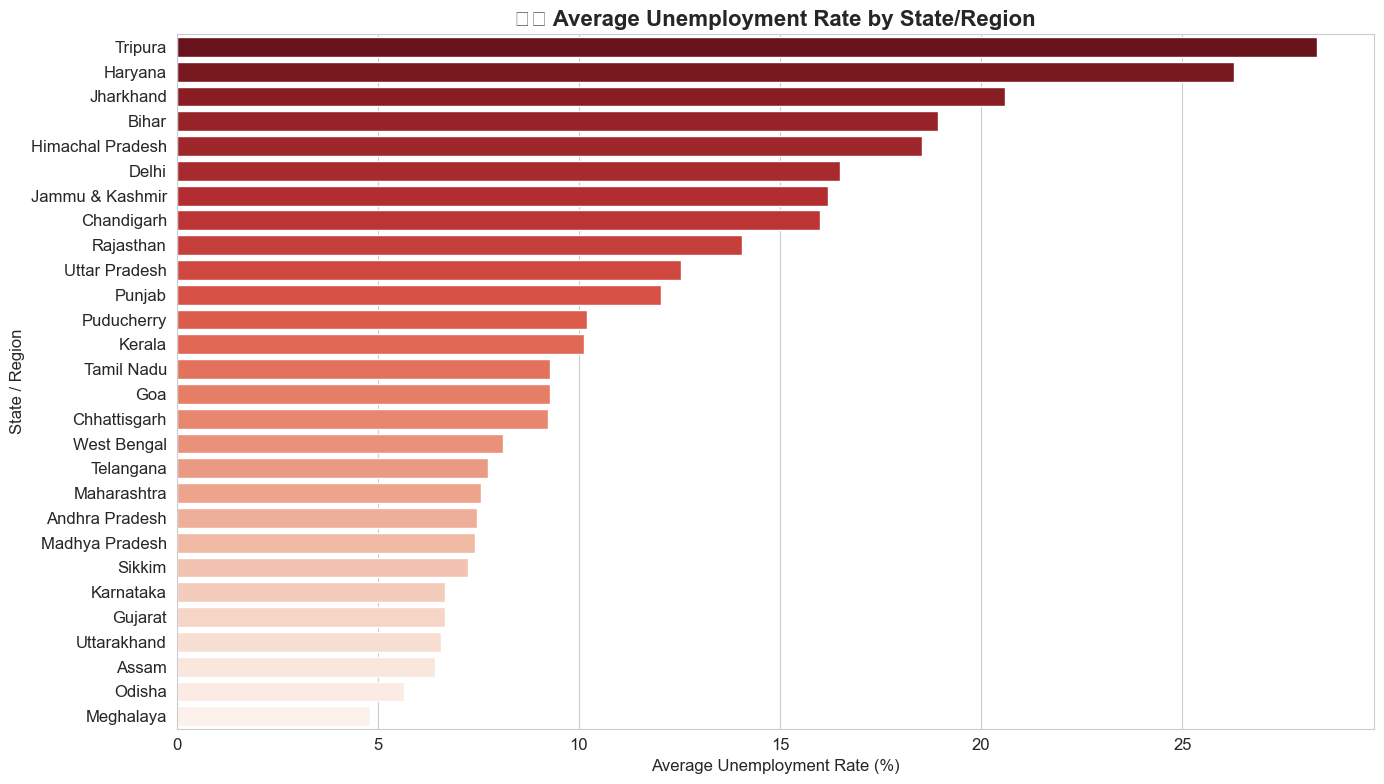


Top 5 States with Highest Unemployment:
          Region  Unemployment_Rate
         Tripura          28.350357
         Haryana          26.283214
       Jharkhand          20.585000
           Bihar          18.918214
Himachal Pradesh          18.540357

Top 5 States with Lowest Unemployment:
     Region  Unemployment_Rate
    Gujarat           6.663929
Uttarakhand           6.582963
      Assam           6.428077
     Odisha           5.657857
  Meghalaya           4.798889


In [10]:
state_avg = df.groupby('Region')['Unemployment_Rate'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(14, 8))
bars = sns.barplot(data=state_avg, x='Unemployment_Rate', y='Region', palette='Reds_r')
plt.title('🗺️ Average Unemployment Rate by State/Region', fontsize=16, fontweight='bold')
plt.xlabel('Average Unemployment Rate (%)')
plt.ylabel('State / Region')
plt.tight_layout()
plt.show()

print("\nTop 5 States with Highest Unemployment:")
print(state_avg.head(5).to_string(index=False))
print("\nTop 5 States with Lowest Unemployment:")
print(state_avg.tail(5).to_string(index=False))


## 7. 🦠 Covid-19 Impact Analysis

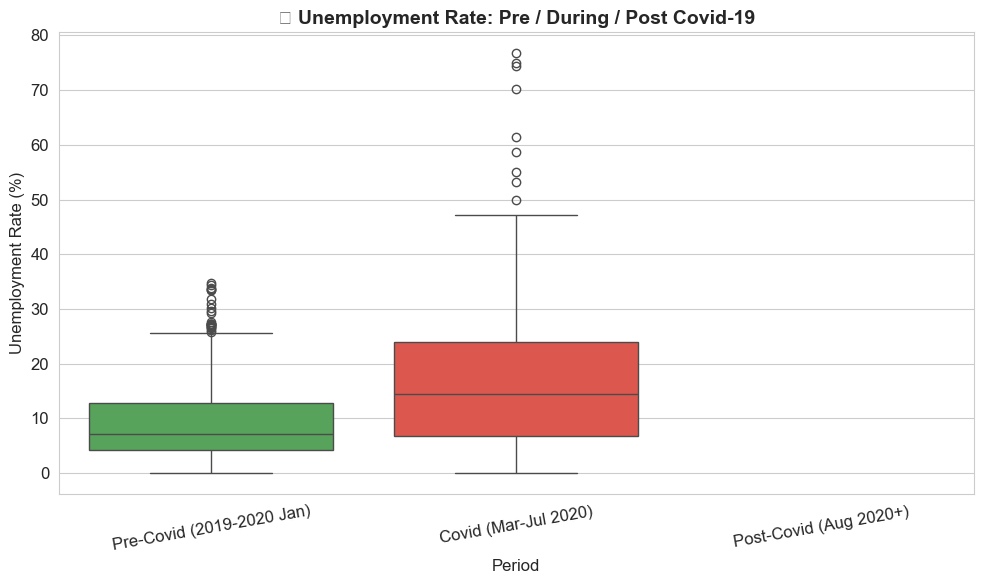

Period-wise Average Unemployment Rate:
Period
Covid (Mar-Jul 2020)         17.77
Pre-Covid (2019-2020 Jan)     9.51
Name: Unemployment_Rate, dtype: float64


In [11]:
df['Period'] = df['Date'].apply(lambda x: 'Pre-Covid (2019-2020 Jan)' if x < pd.Timestamp('2020-03-01')
                                  else ('Covid (Mar-Jul 2020)' if x <= pd.Timestamp('2020-07-31')
                                        else 'Post-Covid (Aug 2020+)'))

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Period', y='Unemployment_Rate',
            order=['Pre-Covid (2019-2020 Jan)', 'Covid (Mar-Jul 2020)', 'Post-Covid (Aug 2020+)'],
            palette=['#4CAF50', '#F44336', '#FF9800'])
plt.title('🦠 Unemployment Rate: Pre / During / Post Covid-19', fontsize=14, fontweight='bold')
plt.xlabel('Period')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

print("Period-wise Average Unemployment Rate:")
print(df.groupby('Period')['Unemployment_Rate'].mean().round(2))


## 8. 🌡️ State × Month Unemployment Heatmap

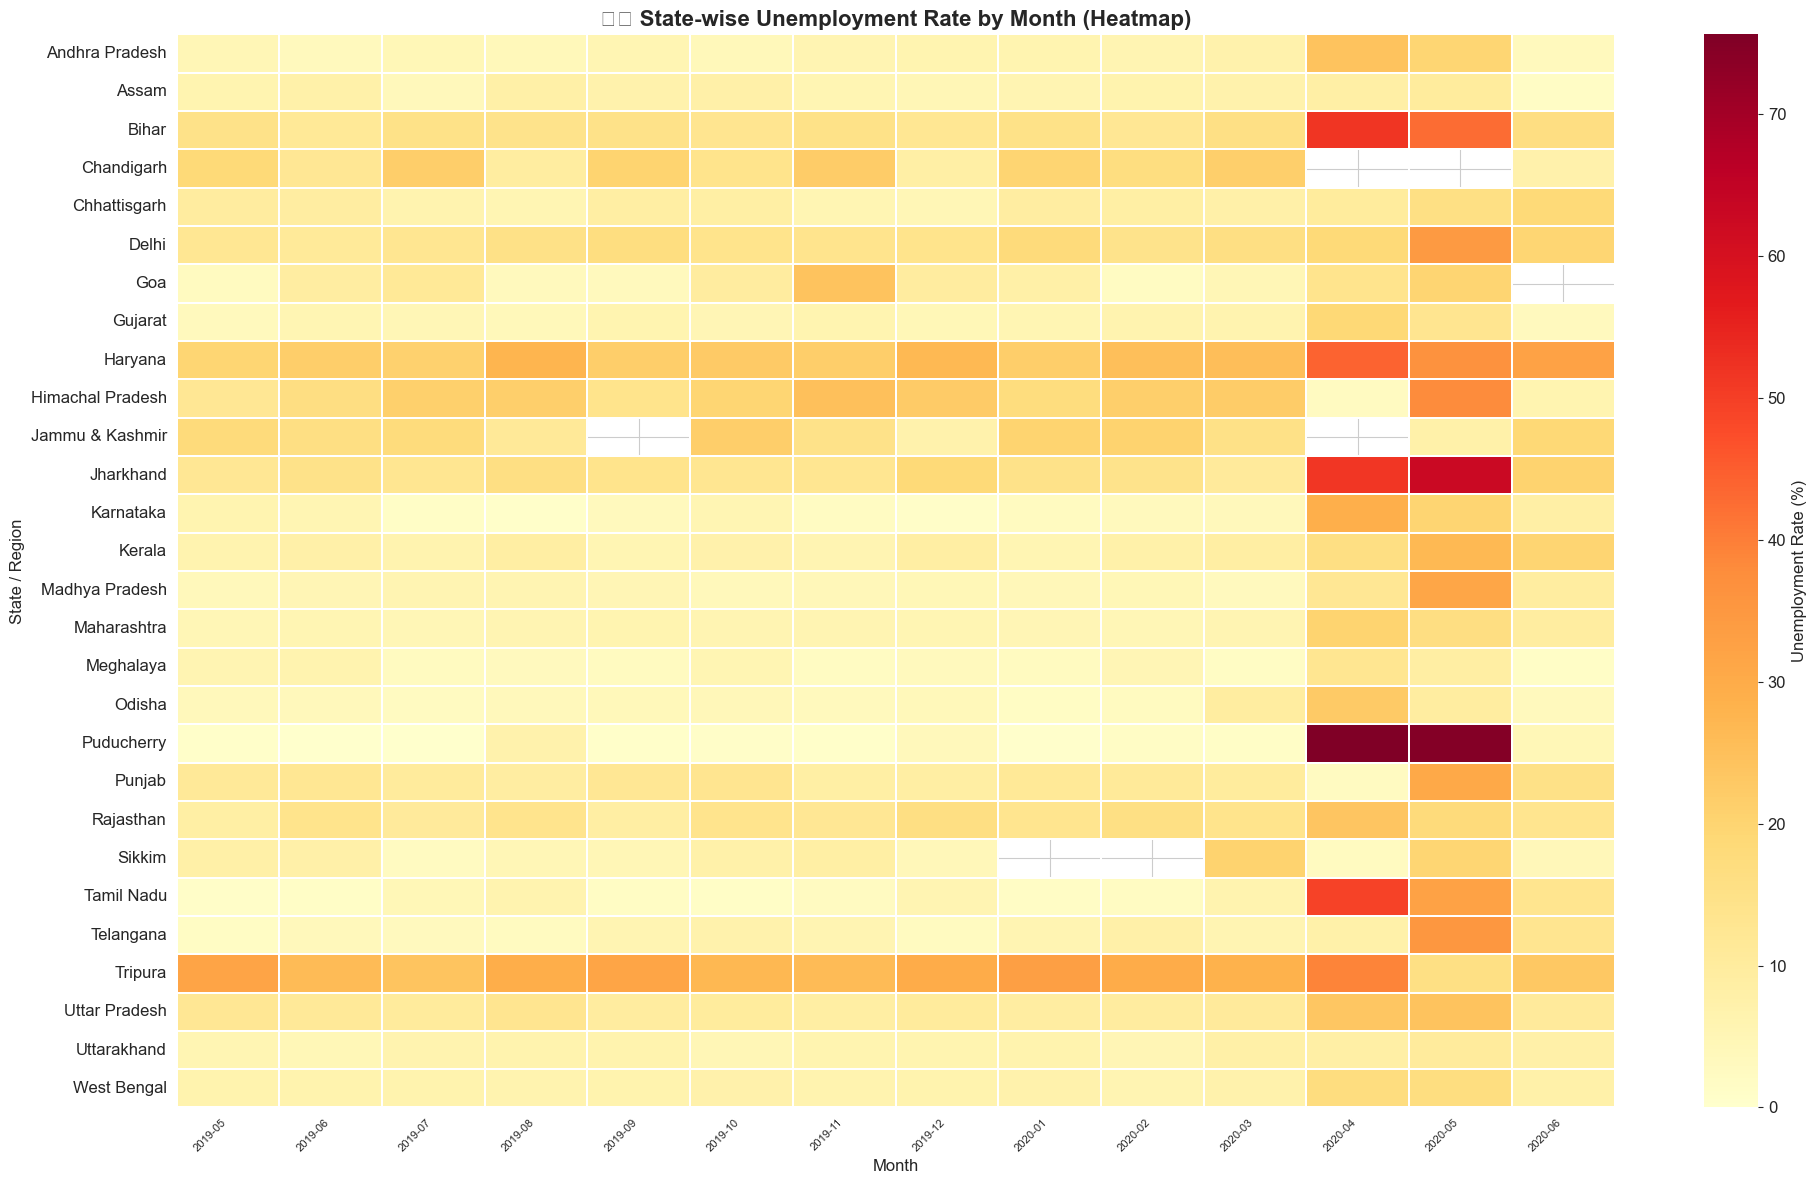

In [12]:
df['Month_Year'] = df['Date'].dt.to_period('M').astype(str)

pivot = df.pivot_table(index='Region', columns='Month_Year', values='Unemployment_Rate', aggfunc='mean')

plt.figure(figsize=(20, 12))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.3, linecolor='white',
            cbar_kws={'label': 'Unemployment Rate (%)'})
plt.title('🌡️ State-wise Unemployment Rate by Month (Heatmap)', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('State / Region')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()


## 9. 👷 Labour Participation Rate Analysis

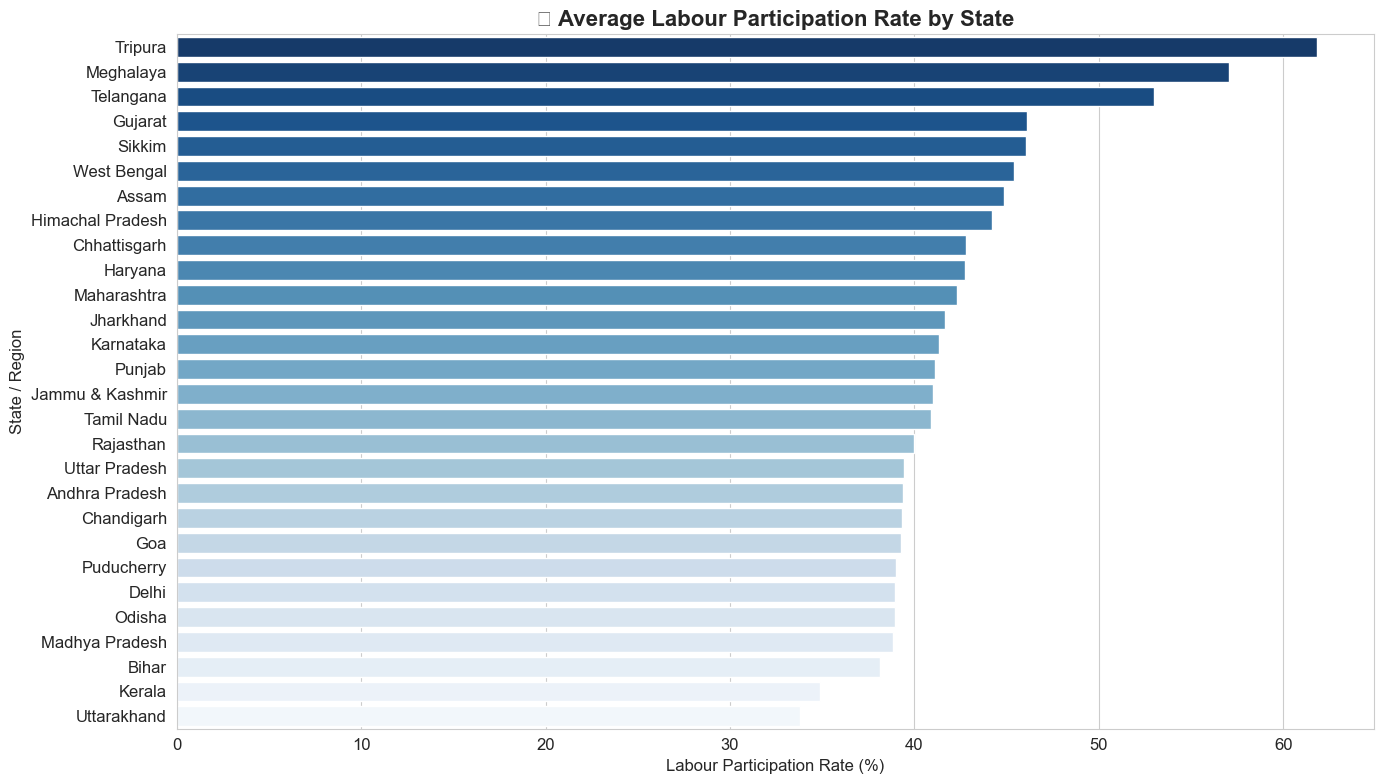

In [13]:
lpr_state = df.groupby('Region')['Labour_Participation_Rate'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(14, 8))
sns.barplot(data=lpr_state, x='Labour_Participation_Rate', y='Region', palette='Blues_r')
plt.title('👷 Average Labour Participation Rate by State', fontsize=16, fontweight='bold')
plt.xlabel('Labour Participation Rate (%)')
plt.ylabel('State / Region')
plt.tight_layout()
plt.show()


## 10. 🔗 Correlation Between Key Variables

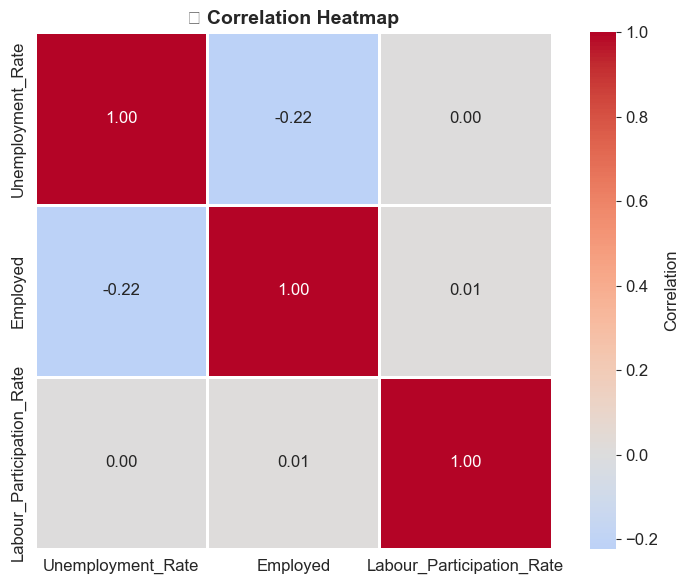


Key Insight:
- Negative correlation between Unemployment Rate and Labour Participation Rate suggests
  that as more people participate in the workforce, unemployment tends to drop.


In [14]:
corr_cols = ['Unemployment_Rate', 'Employed', 'Labour_Participation_Rate']
corr = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=1, square=True, cbar_kws={'label': 'Correlation'})
plt.title('🔗 Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKey Insight:")
print("- Negative correlation between Unemployment Rate and Labour Participation Rate suggests")
print("  that as more people participate in the workforce, unemployment tends to drop.")


## 11. 📍 Top 10 Most Affected States During Covid Lockdown

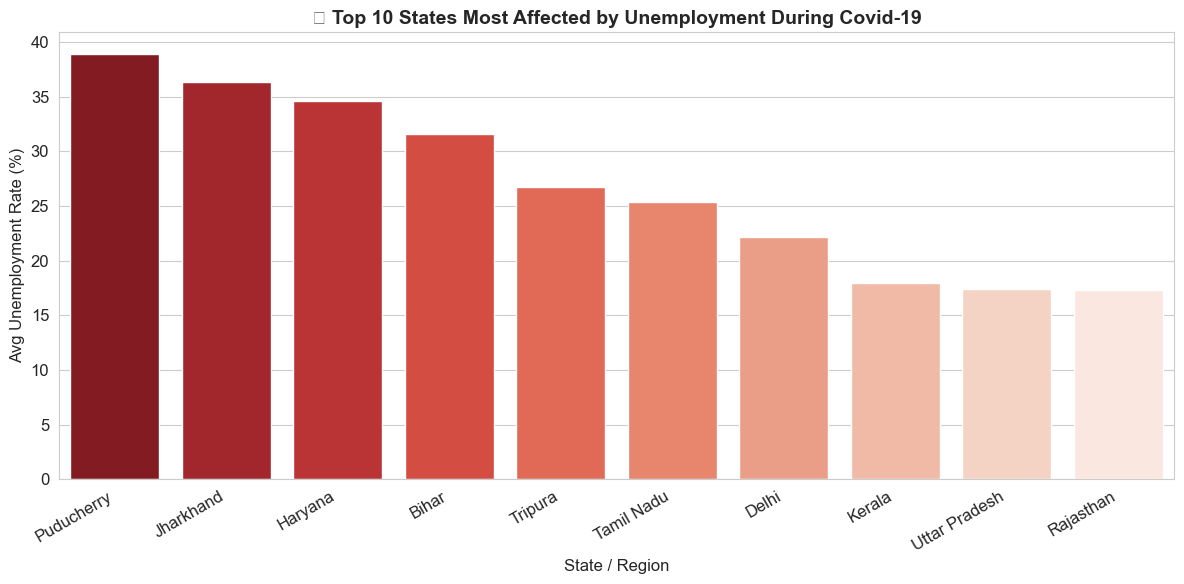

In [15]:
covid_df = df[df['Period'] == 'Covid (Mar-Jul 2020)']
covid_state = covid_df.groupby('Region')['Unemployment_Rate'].mean().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=covid_state, x='Region', y='Unemployment_Rate', palette='Reds_r')
plt.title('📍 Top 10 States Most Affected by Unemployment During Covid-19', fontsize=14, fontweight='bold')
plt.xlabel('State / Region')
plt.ylabel('Avg Unemployment Rate (%)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


## 12. 📝 Key Findings & Summary

| # | Finding |
|---|---------|
| 1 | India's unemployment rate **spiked sharply** during the Covid-19 lockdown (April–May 2020). |
| 2 | **Urban areas** experienced higher unemployment than rural areas, especially during Covid. |
| 3 | States like **Haryana, Tripura, and Jharkhand** consistently showed higher unemployment. |
| 4 | **Labour Participation Rate** and **Unemployment Rate** are negatively correlated. |
| 5 | Post-Covid recovery showed a **gradual decline** in unemployment, but not to pre-Covid levels. |

---

> 🏁 **Conclusion**: Covid-19 had a massive and unprecedented impact on India's labour market. Urban workers and specific states were hit the hardest. Data-driven policy interventions targeting these regions and demographics are essential for economic recovery.
